In [ ]:
# Data handling
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import warnings as wr
wr.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

### 1.Logistic regression

In [2]:
# Features we need based on EDA 
features_scaled = ["age", "sex", "bmi", "bp", "s3", "s5"]

# We load the mean centered dataset for Logistic Regression
diabetes_data = load_diabetes()
df_mean_centered = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df_mean_centered["y"] = diabetes_data.target
df_mean_centered["y"] = df_mean_centered["y"].astype("Int64")
df_mean_centered = df_mean_centered[features_scaled + ["y"]]       

print(f"Shape of the dataset: {df_mean_centered.shape}")
df_mean_centered.sample(5)

Shape of the dataset: (442, 7)


,age,sex,bmi,bp,s3,s5,y
406,-0.056370,-0.044642,-0.080575,-0.084856,0.033914,-0.056153,72
159,-0.005515,-0.044642,0.043373,0.087287,-0.013948,0.042341,195
321,0.096197,-0.044642,0.051996,0.079265,-0.076536,0.098648,230
278,0.067136,0.050680,-0.036385,-0.084856,-0.054446,0.001148,102
376,-0.001882,-0.044642,0.068163,-0.005670,-0.024993,0.046133,121


In [3]:
# Switch out the data for binary classification based on treshold 1
df_mean_centered["y"] = (df_mean_centered["y"] >= 150).astype(int)
print(df_mean_centered.sample(5))

# Create the X and Y variables and splitting them to test and train variables
X_scaled = df_mean_centered[features_scaled]
print(X_scaled.sample(5))
y = df_mean_centered["y"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nLogistic Regression — Train: {X_train_lr.shape}, Test: {X_test_lr.shape}")
print("\nLR Train balance:")
print(y_train_lr.value_counts(normalize=True).round(3))

         age       sex       bmi        bp        s3        s5  y
74  0.012648  0.050680  0.002417  0.056301  0.041277  0.003709  0
49 -0.041840  0.050680  0.014272 -0.005670 -0.072854  0.035459  0
67  0.041708  0.050680 -0.014828 -0.017135 -0.013948 -0.011897  0
93 -0.049105 -0.044642 -0.064408 -0.102070  0.063367 -0.033246  0
95 -0.070900 -0.044642 -0.057941 -0.081413 -0.043401  0.001148  1
          age       sex       bmi        bp        s3        s5
21  -0.085430  0.050680 -0.022373  0.001215  0.015505 -0.072133
408  0.063504 -0.044642 -0.050396  0.107944 -0.017629  0.058038
149 -0.049105  0.050680 -0.005128 -0.046985 -0.069172  0.061238
357 -0.060003  0.050680  0.049840  0.018430 -0.017629  0.049770
270  0.005383  0.050680  0.030440  0.083844  0.015505  0.008641

Logistic Regression — Train: (353, 6), Test: (89, 6)

LR Train balance:
y
0    0.538
1    0.462
Name: proportion, dtype: float64


In [4]:
scaler = StandardScaler()
X_train_lr = pd.DataFrame(scaler.fit_transform(X_train_lr), columns=features_scaled)
X_test_lr = pd.DataFrame(scaler.transform(X_test_lr), columns=features_scaled)

lr_model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_lr, y_train_lr)
print("Logistic Regression model finished training")

Logistic Regression model finished training


### 2. Decision Tree

In [5]:
# Features we need based on EDA 
features_original = ["AGE", "SEX", "BMI", "BP", "S3", "S5"]

# If viewed on mac to bypass SSL cert problem:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

original_data_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

df_original_data = pd.read_csv(original_data_url, sep="\t")
df_original_data = df_original_data[features_original + ["Y"]]       

print(f"Shape of the dataset: {df_original_data.shape}")
df_original_data.sample(5)

Shape of the dataset: (442, 7)


,AGE,SEX,BMI,BP,S3,S5,Y
222,42,2,24.0,107.0,44.0,4.6540,252
409,34,2,25.3,111.0,39.0,4.9767,181
76,40,2,29.0,115.0,35.0,4.3041,170
369,46,1,29.9,83.0,38.0,4.5850,167
120,35,1,26.8,98.0,45.0,4.2047,200


In [6]:
# Switch out the data for binary classification based on treshold 1
df_original_data["Y"] = (df_original_data["Y"] >= 150).astype(int)
print(df_original_data.sample(5))

# Create the X and Y variables and splitting them to test and train variables
X = df_original_data[features_original]
y_tree = df_original_data["Y"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

print(f"\nTree models — Train: {X_train_tree.shape}, Test: {X_test_tree.shape}")
print("\nTree Train balance:")
print(y_train_tree.value_counts(normalize=True).round(3))

     AGE  SEX   BMI     BP    S3      S5  Y
70    48    1  19.9  91.00  69.0  3.9512  0
414   71    2  27.0  93.33  41.0  5.2417  0
62    41    2  25.7  83.00  66.0  3.7377  0
294   55    2  23.5  93.00  41.0  3.8286  0
391   42    1  19.9  76.00  55.0  3.6636  0

Tree models — Train: (353, 6), Test: (89, 6)

Tree Train balance:
Y
0    0.538
1    0.462
Name: proportion, dtype: float64


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train_tree, y_train_tree)
print("Random Forest model finished training ")

Random Forest model finished training 


LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

 Not At Risk       0.73      0.69      0.71        48
     At Risk       0.66      0.71      0.68        41

    accuracy                           0.70        89
   macro avg       0.70      0.70      0.70        89
weighted avg       0.70      0.70      0.70        89

RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

 Not At Risk       0.71      0.71      0.71        48
     At Risk       0.66      0.66      0.66        41

    accuracy                           0.69        89
   macro avg       0.68      0.68      0.68        89
weighted avg       0.69      0.69      0.69        89



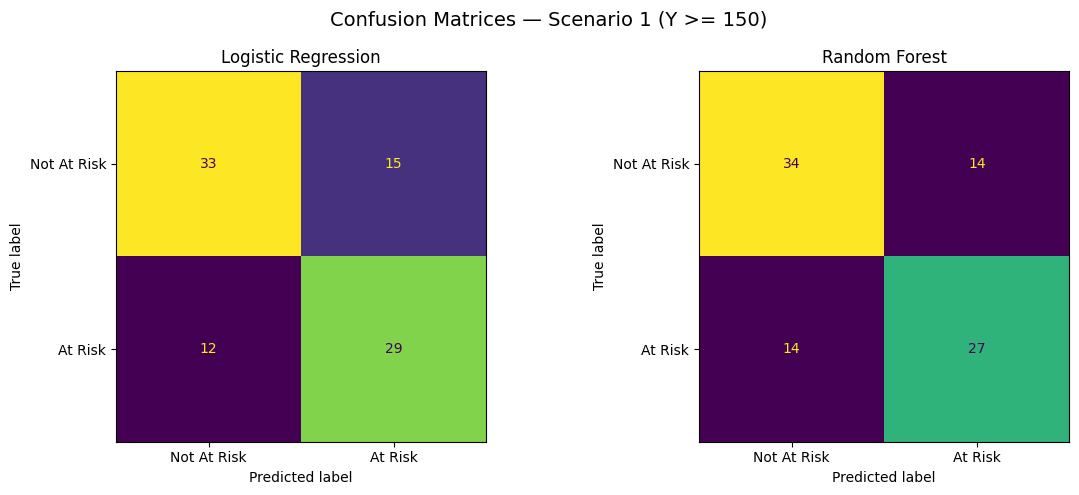

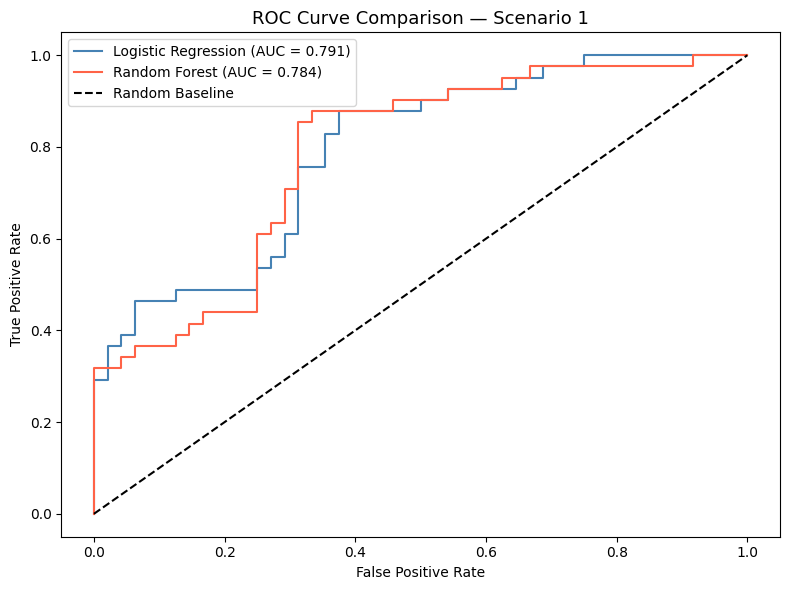

In [8]:
# ── Logistic Regression Evaluation ────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test_lr)
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test_lr, y_pred_lr, target_names=["Not At Risk", "At Risk"]))

# ── Random Forest Evaluation ───────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test_tree)
y_prob_rf = rf_model.predict_proba(X_test_tree)[:, 1]

print("=" * 50)
print("RANDOM FOREST — Classification Report")
print("=" * 50)
print(classification_report(y_test_tree, y_pred_rf, target_names=["Not At Risk", "At Risk"]))

# ── Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices — Scenario 1 (Y >= 150)", fontsize=14)

ConfusionMatrixDisplay(confusion_matrix(y_test_lr, y_pred_lr),
                       display_labels=["Not At Risk", "At Risk"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test_tree, y_pred_rf),
                       display_labels=["Not At Risk", "At Risk"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

# ── ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_tree, y_prob_rf)

ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test_lr, y_prob_lr):.3f})", color="steelblue")
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test_tree, y_prob_rf):.3f})", color="tomato")
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")

ax.set_title("ROC Curve Comparison — Scenario 1", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Cross-validation will give you a more reliable accuracy estimate
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(lr_model, X_train_lr, y_train_lr, cv=5, scoring='roc_auc')
rf_cv = cross_val_score(rf_model, X_train_tree, y_train_tree, cv=5, scoring='roc_auc')

print(f"LR Cross-val AUC: {lr_cv.mean():.3f} (+/- {lr_cv.std():.3f})")
print(f"RF Cross-val AUC: {rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})")

LR Cross-val AUC: 0.851 (+/- 0.032)
RF Cross-val AUC: 0.831 (+/- 0.037)


LOGISTIC REGRESSION — Feature Coefficients
Feature  Coefficient
     s5     0.835316
     bp     0.742708
    bmi     0.606476
    sex    -0.481523
     s3    -0.352625
    age     0.061544


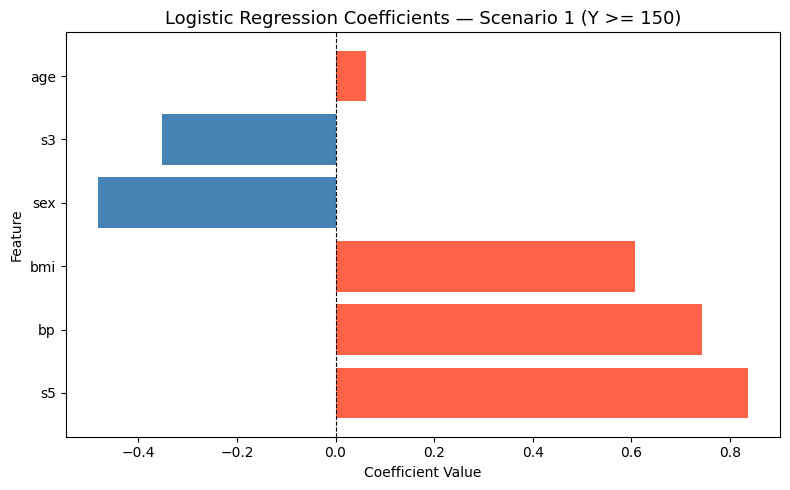

In [10]:
# ── Feature Coefficients — Logistic Regression ────────────────────────────
coef_df = pd.DataFrame({
    "Feature": features_scaled,
    "Coefficient": lr_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("=" * 45)
print("LOGISTIC REGRESSION — Feature Coefficients")
print("=" * 45)
print(coef_df.to_string(index=False))

# ── Visualise coefficients ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Logistic Regression Coefficients — Scenario 1 (Y >= 150)", fontsize=13)
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()